In [122]:
import warnings
warnings.filterwarnings("ignore")

from torch_geometric.loader import DataLoader

from pathlib import Path
import wandb
import torch
import os

## plotting
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle
from scipy.sparse import issparse

# single cell tools
import scanpy as sc
import squidpy as sq
from anndata import AnnData

In [123]:
FOLDER = "legnini23"
GEX_DATA = "legnini23_None_sample_1_44"

In [124]:
from graph_transformer_long_range_niches.tl import pad_batch, load_model
from graph_transformer_long_range_niches._paths import CFG_FILES, RESULTS, FIG_PATH, LEGNINI23

In [187]:
SHH_MARKERS = ["FOXA1", "FOXA2", "NKX2.2", "MNX1", "OLIG1", "OLIG2", "NKX6.2", "NKX6.1", "NEUROD1", "PAX6", "IRX3", "OTP", "OTX2", "DBX2", "DBX1"]

# Basline 

In [125]:
model_transformer_gex, cfg_gex, obs_gex = load_model(GEX_DATA, model_type = "gnn-transformer")

num features: 88


In [126]:
adata = sc.read_h5ad(Path(LEGNINI23))
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'raw'

## Baseline model: Implementation

In [127]:
cfg = cfg_gex

In [128]:
adata.obs[spatial_neigbors_kwargs.library_key]

0        slide1_A2-1
1        slide1_A2-1
2        slide1_A2-1
3        slide1_A2-1
4        slide1_A2-1
            ...     
43757    slide4_B2-3
43758    slide4_B2-3
43759    slide4_B2-3
43760    slide4_B2-3
43761    slide4_B2-3
Name: sample, Length: 43762, dtype: category
Categories (17, object): ['slide1_A2-1', 'slide1_A2-2', 'slide1_B2-1', 'slide1_B2-2', ..., 'slide4_A2-3', 'slide4_B2-1', 'slide4_B2-2', 'slide4_B2-3']

In [129]:
category_to_iterate_list = cfg.dataset.library_key
spatial_neigbors_kwargs = cfg.dataset.spatial_neigbors_kwargs

# sq.gr.spatial_neighbors(
#     adata,
#     radius=spatial_neigbors_kwargs.radius,
#     coord_type=spatial_neigbors_kwargs.coord_type,
#     library_key = spatial_neigbors_kwargs.library_key
# )
sq.gr.spatial_neighbors(
    adata,
    radius=200,
    coord_type=spatial_neigbors_kwargs.coord_type,
    library_key = spatial_neigbors_kwargs.library_key
)

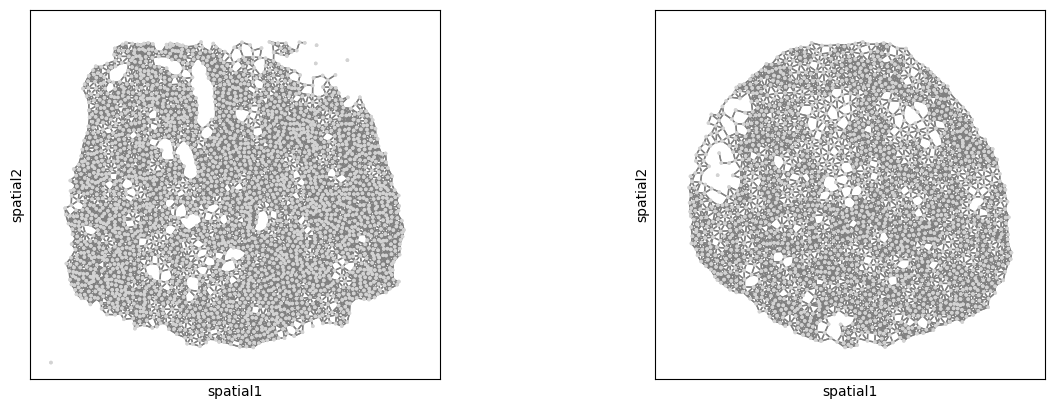

In [130]:
sq.pl.spatial_scatter(
    adata,
    library_key = spatial_neigbors_kwargs.library_key,
    library_id = ['slide1_A2-1', 'slide4_A2-3'],
    connectivity_key="spatial_connectivities",
    img=False,
    na_color="lightgrey",
    size=10,
    shape = None,
)

In [131]:
conn = adata.obsp['spatial_connectivities']

In [132]:
# Print average number of connections per node
avg_connections = conn.nnz / conn.shape[0]  # total connections / number of nodes
print(f"Average number of connections per node: {avg_connections:.2f}")

Average number of connections per node: 10.14


In [133]:
# Add self-connections
import scipy
conn = conn + scipy.sparse.csr_matrix(np.eye(conn.shape[0]))

In [134]:
assert avg_connections + 1 == conn.nnz / conn.shape[0]

In [135]:
# Normalize connections
conn = conn.multiply(1/conn.sum(axis=1))

# Aggregate expression
adata.layers['aggregated'] = conn @ adata.X

In [136]:
adata.X = adata.layers['aggregated']

In [147]:
sample_id_ctrl = 'slide4_A2-3'
sample_id_shh = 'slide4_B2-2'

In [167]:
sub_adata_ctrl = adata[adata.obs['sample'] == sample_id_ctrl]
sub_adata_shh = adata[adata.obs['sample'] == sample_id_shh]

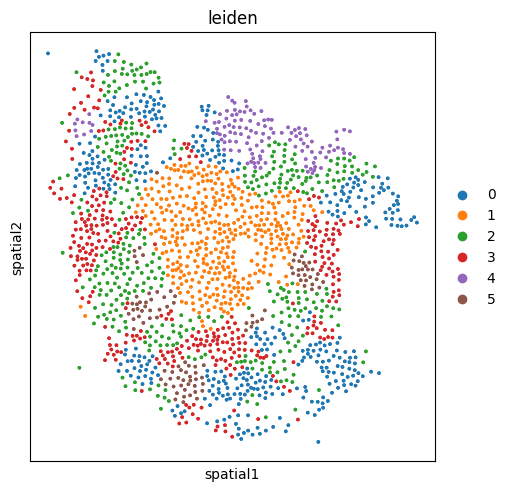

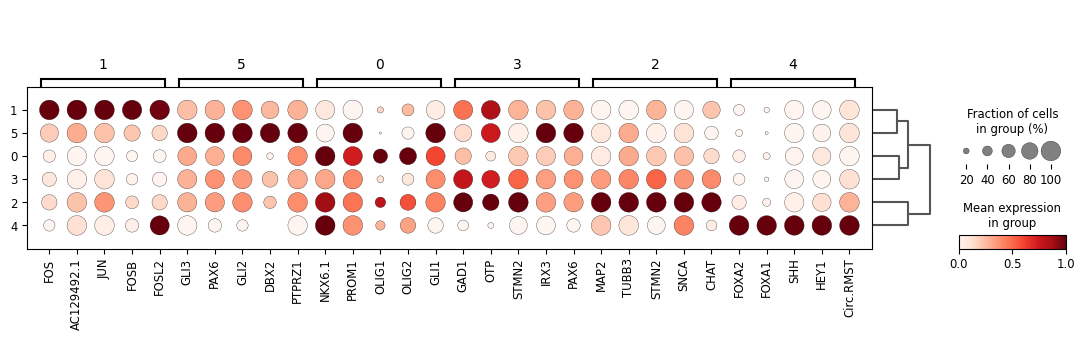

In [178]:
# Run Leiden clustering on aggregated expression
sc.pp.neighbors(sub_adata_shh, n_neighbors = 40, use_rep='X')
sc.tl.leiden(
    sub_adata_shh,
    resolution=0.3,
    use_weights=True,
    key_added='leiden'
)
clusters = sub_adata_shh.obs['leiden']
sq.pl.spatial_scatter(
    sub_adata_shh,
    library_key = spatial_neigbors_kwargs.library_key,
    img=False,
    color= 'leiden',
    size=10,
    shape = None,
)
sc.tl.rank_genes_groups(sub_adata_shh, groupby='leiden', method='wilcoxon', key_added = 'dge_wilcoxon_shh')
sc.pl.rank_genes_groups_dotplot(
    sub_adata_shh,
    groupby="leiden",
    standard_scale="var",
    n_genes=5,
    key="dge_wilcoxon_shh",
)

In [207]:
# Run Leiden clustering on aggregated expression
sc.pp.neighbors(sub_adata_ctrl, n_neighbors = 40, use_rep='X')
sc.tl.leiden(
    sub_adata_ctrl,
    resolution=0.3,
    use_weights=True,
    key_added='leiden'
)

In [208]:
clusters = sub_adata_ctrl.obs['leiden']

In [209]:
del sub_adata_ctrl.uns['leiden_colors']

KeyError: 'leiden_colors'

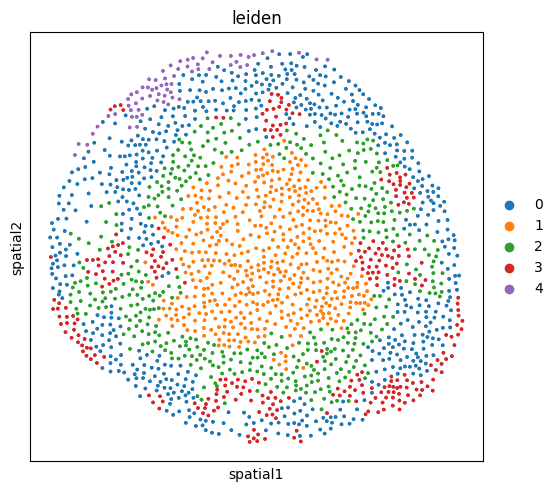

In [210]:
sq.pl.spatial_scatter(
    sub_adata_ctrl,
    library_key = spatial_neigbors_kwargs.library_key,
    img=False,
    color= 'leiden',
    size=10,
    shape = None,
)

In [211]:
# Perform DGE analysis
sc.tl.rank_genes_groups(sub_adata_ctrl, groupby='leiden_ctrl', method='wilcoxon', key_added = 'dge_wilcoxon_ctrl')

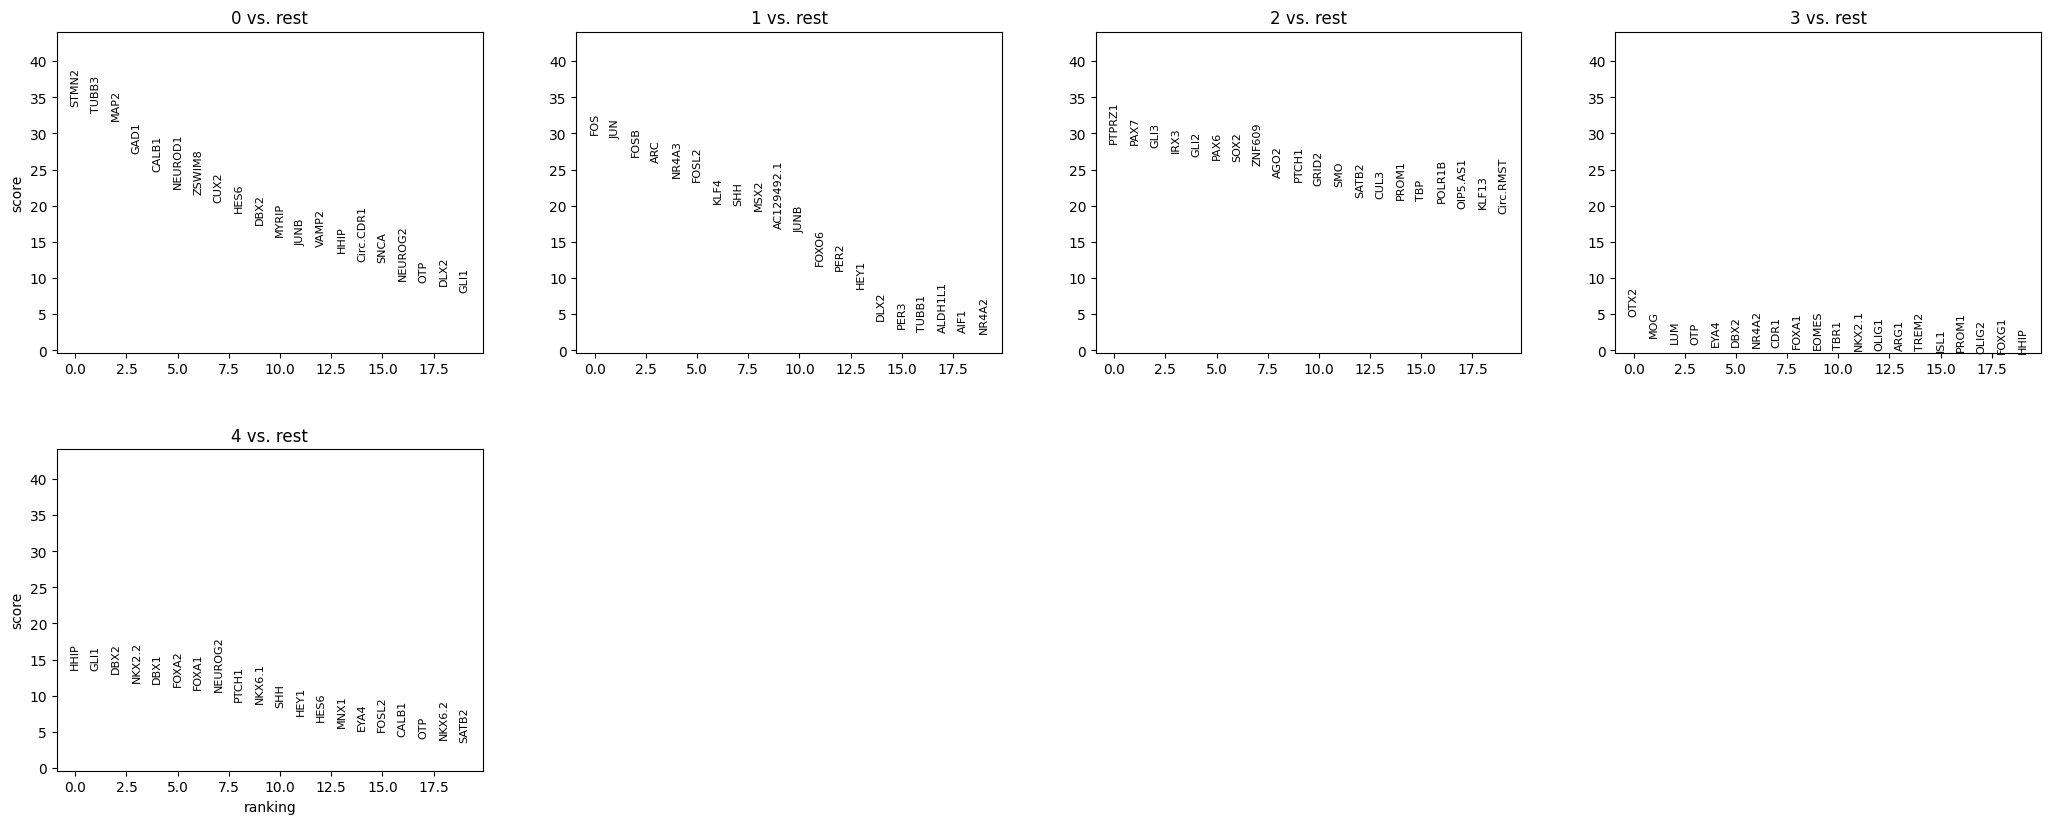

In [212]:
sc.pl.rank_genes_groups(sub_adata_ctrl, key = 'dge_wilcoxon_ctrl')

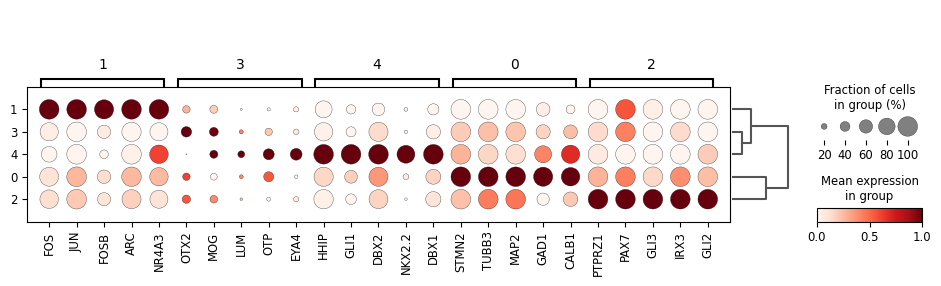

In [165]:
sc.pl.rank_genes_groups_dotplot(
    sub_adata_ctrl,
    groupby="leiden_ctrl",
    standard_scale="var",
    n_genes=5,
    key="dge_wilcoxon_ctrl",
)

### Overlapping marker genes

How many genes does the leiden clustering identify as significant?

In [220]:
def overlapping_marker_genes(adata, markers_list, dge_key: str = 'dge_wilcoxon', top_n: int = 10):
    # Extract rank_genes_groups result
    ranked_genes = adata.uns[dge_key]['names']  # 2D array (clusters x genes)
    
    # Initialize a dictionary to store marker overlaps for each cluster
    overlap = set()
    
    # Loop through each cluster's ranked genes
    for idx in range(top_n):
        top_genes = ranked_genes[idx]
        
        # Find the overlap with Shh markers
        overlap.update([gene for gene in top_genes if gene in markers_list])
    
    print(f"{len(overlap)} Shh markers found (total: {len(markers_list)}) - {overlap}")

In [222]:
overlapping_marker_genes(sub_adata_ctrl, SHH_MARKERS, dge_key = 'dge_wilcoxon_ctrl', top_n = 10)
overlapping_marker_genes(sub_adata_shh, SHH_MARKERS, dge_key = 'dge_wilcoxon_shh', top_n = 10)

9 Shh markers found (total: 15) - {'OTP', 'FOXA1', 'DBX2', 'IRX3', 'DBX1', 'FOXA2', 'OTX2', 'NEUROD1', 'PAX6'}
8 Shh markers found (total: 15) - {'OTP', 'FOXA1', 'OLIG2', 'DBX2', 'IRX3', 'OLIG1', 'FOXA2', 'PAX6'}
